In [1]:
!pip install pennylane pennylane-lightning torch torchvision scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.9 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving X_test_pca.npy to X_test_pca.npy
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Saving X_train_pca.npy to X_train_pca.npy


In [3]:
import numpy as np
import torch

X_train = np.load("X_train_pca.npy")
X_test = np.load("X_test_pca.npy")

y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(X_test.shape)

torch.Size([2000, 4])
torch.Size([500, 4])


In [4]:
import pennylane as qml
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

In [5]:
n_qubits = 4

dev = qml.device(
    "lightning.qubit",
    wires=n_qubits
)

In [7]:
import pennylane as qml

@qml.qnode(dev, interface="torch")
def avqfm_circuit(inputs, weights):

    for i in range(n_qubits):
        qml.RY(
            inputs[i],
            wires=i
        )

    # Qubit 0
    qml.RY(weights[0], wires=0)

    # Qubit 1
    qml.RY(weights[1], wires=1)
    qml.RY(weights[2], wires=1)

    # Qubit 2
    qml.RY(weights[3], wires=2)
    qml.RY(weights[4], wires=2)
    qml.RY(weights[5], wires=2)

    # Qubit 3
    qml.RY(weights[6], wires=3)
    qml.RY(weights[7], wires=3)
    qml.RY(weights[8], wires=3)
    qml.RY(weights[9], wires=3)

    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(4)
    ]

In [8]:
import torch
import torch.nn as nn

class AVQFM(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(10)
        )

        self.fc = nn.Linear(
            4,
            1
        )

    def forward(self, x):

        outputs = []

        for sample in x:

            q_out = avqfm_circuit(
                sample,
                self.q_weights
            )

            outputs.append(
                torch.stack(q_out)
            )

        outputs = torch.stack(
            outputs
        )

        out = self.fc(outputs)

        return torch.sigmoid(
            out.squeeze()
        )

In [9]:
model = AVQFM()

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

In [10]:
preds = model(X_train[:5])

print(preds)

tensor([0.4063, 0.5361, 0.5264, 0.5083, 0.4912], grad_fn=<SigmoidBackward0>)


In [11]:
epochs = 30

loss_history = []
gradient_variance_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    preds = model(X_train)

    loss = criterion(
        preds,
        y_train
    )

    loss.backward()

    grad_values = []

    for p in model.parameters():
        grad_values.extend(
            p.grad.detach()
            .cpu()
            .numpy()
            .flatten()
        )

    grad_var = np.var(
        grad_values
    )

    gradient_variance_history.append(
        grad_var
    )

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss.item():.4f} | "
        f"GradVar={grad_var:.8f}"
    )

Epoch 01 | Loss=0.6913 | GradVar=0.00398390
Epoch 02 | Loss=0.6869 | GradVar=0.00378555
Epoch 03 | Loss=0.6825 | GradVar=0.00366716
Epoch 04 | Loss=0.6783 | GradVar=0.00355374
Epoch 05 | Loss=0.6741 | GradVar=0.00344308
Epoch 06 | Loss=0.6700 | GradVar=0.00333480
Epoch 07 | Loss=0.6661 | GradVar=0.00322898
Epoch 08 | Loss=0.6622 | GradVar=0.00312590
Epoch 09 | Loss=0.6586 | GradVar=0.00302592
Epoch 10 | Loss=0.6550 | GradVar=0.00292943
Epoch 11 | Loss=0.6516 | GradVar=0.00283681
Epoch 12 | Loss=0.6483 | GradVar=0.00274839
Epoch 13 | Loss=0.6452 | GradVar=0.00266436
Epoch 14 | Loss=0.6422 | GradVar=0.00258486
Epoch 15 | Loss=0.6393 | GradVar=0.00250983
Epoch 16 | Loss=0.6365 | GradVar=0.00243914
Epoch 17 | Loss=0.6339 | GradVar=0.00237255
Epoch 18 | Loss=0.6312 | GradVar=0.00230981
Epoch 19 | Loss=0.6287 | GradVar=0.00225068
Epoch 20 | Loss=0.6262 | GradVar=0.00219497
Epoch 21 | Loss=0.6237 | GradVar=0.00214252
Epoch 22 | Loss=0.6213 | GradVar=0.00209328
Epoch 23 | Loss=0.6189 | GradVar

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

with torch.no_grad():

    probs = model(X_test)

preds = (probs > 0.5).int()

acc = accuracy_score(
    y_test.numpy(),
    preds.numpy()
)

f1 = f1_score(
    y_test.numpy(),
    preds.numpy()
)

print("Accuracy =", acc)
print("F1 Score =", f1)

Accuracy = 0.792
F1 Score = 0.8327974276527331


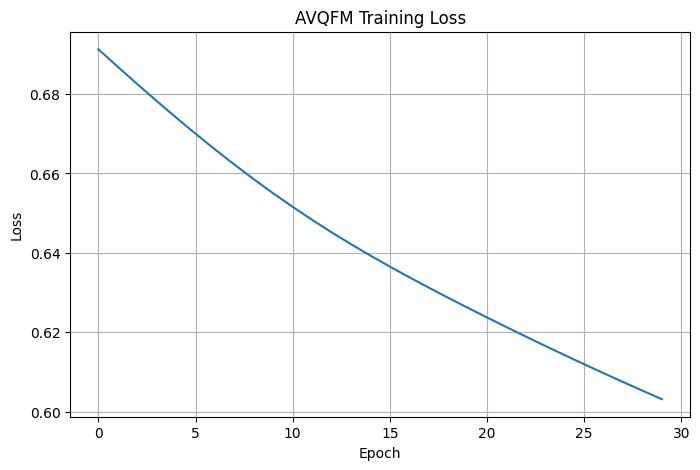

In [13]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AVQFM Training Loss")
plt.grid(True)

plt.savefig(
    "Fig_AVQFM_Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

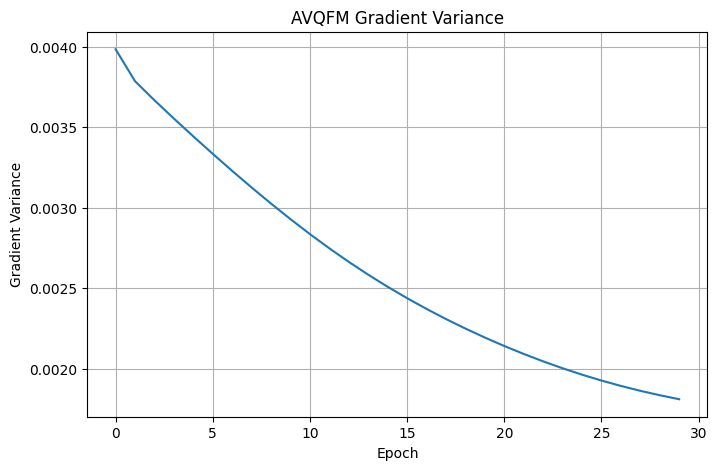

In [14]:
plt.figure(figsize=(8,5))
plt.plot(gradient_variance_history)

plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("AVQFM Gradient Variance")

plt.grid(True)

plt.savefig(
    "Fig_AVQFM_Gradient_Variance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

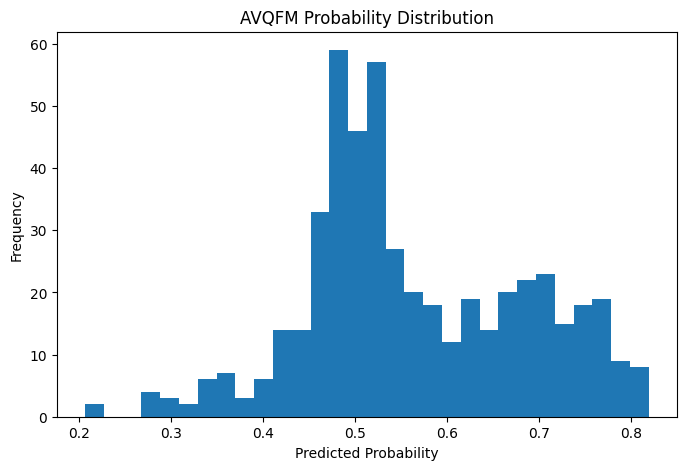

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    probs.numpy(),
    bins=30
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")

plt.title("AVQFM Probability Distribution")

plt.savefig(
    "Fig_AVQFM_Probability_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

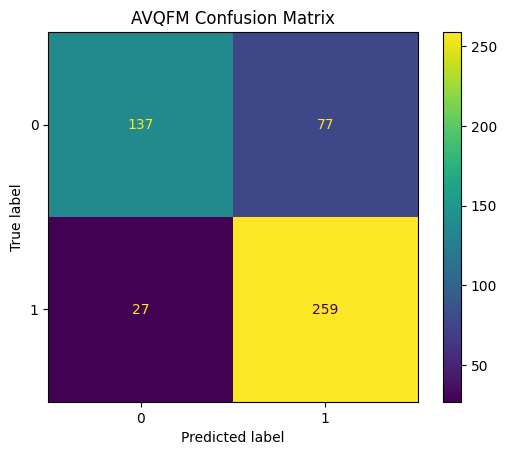

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test.numpy(),
    preds.numpy()
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("AVQFM Confusion Matrix")

plt.savefig(
    "Fig_AVQFM_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from google.colab import files

files.download("Fig_AVQFM_Training_Loss.png")
files.download("Fig_AVQFM_Gradient_Variance.png")
files.download("Fig_AVQFM_Probability_Distribution.png")
files.download("Fig_AVQFM_Confusion_Matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>